## Данные

Набор данных вы сможете скачать, перейдя по [ссылке](https://disk.yandex.ru/d/zL5QhX7As8Ihaw).

Второй тестовый набор будет доступен по ссылке 14 сентября.

## Метрика

MAPE

## Важно

Уважаемые участники! Для воспроизводимости ваших результатов при проверке, обязательно фиксируйте seed генераторов случайных чисел при обучении ваших алгоритмов. Записывайте seed в имя файла с ответами. Выбирайте seed каждый раз случайным образом и всегда записывайте его в имя файла с ответами для воспроизводимости результатов.


In [ ]:
import random

seed = 826
random.seed(seed)
print(seed)

826


In [ ]:
import pandas as pd

data = pd.read_csv('train.csv')

data.fillna(-1, inplace=True)



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Создаем объект LabelEncoder
le = LabelEncoder()

# Применяем LabelEncoder к столбцу 'Тип_жилья'
data['Тип_жилья'] = le.fit_transform(data['Тип_жилья'])


type_town = pd.unique(data['Город'])
for i in range(len(type_town)):
    data['Город'] = data['Город'].replace(type_town[i], len(type_town[i]))


type_h=pd.unique(data['Ктгр_энергоэффективности'])
for i in range(len(type_h)):
    data['Ктгр_энергоэффективности'] = data['Ктгр_энергоэффективности'].replace(type_h[i], i + 1)

type_he=pd.unique(data['Ктгр_вредных_выбросов'])
for i in range(len(type_he)):
    data['Ктгр_вредных_выбросов'] = data['Ктгр_вредных_выбросов'].replace(type_he[i], i + 1)

type_n=pd.unique(data['Направление'])
for i in range(len(type_n)):
    data['Направление'] = data['Направление'].replace(type_n[i], i + 1)

In [ ]:
# data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,26157.0,3.569053e+07,1.445742e+06,6.774630e+06,3.580803e+07,3.587050e+07,3.601060e+07,3.609881e+07
Тип_жилья,26157.0,4.523990e+00,4.265881e+00,0.000000e+00,1.000000e+00,6.000000e+00,6.000000e+00,2.000000e+01
Широта,26157.0,4.655385e+01,2.363399e+00,4.137444e+01,4.392953e+01,4.696036e+01,4.884430e+01,5.107589e+01
Долгота,26157.0,2.621490e+00,2.600275e+00,-4.707048e+00,1.095586e+00,2.381940e+00,4.620281e+00,9.502115e+00
Город,26157.0,1.107046e+01,5.250358e+00,2.000000e+00,7.000000e+00,1.000000e+01,1.500000e+01,3.500000e+01
Индекс,26157.0,2.559785e+03,1.471528e+03,0.000000e+00,1.315000e+03,2.692000e+03,3.847000e+03,4.725000e+03
Площадь,26157.0,1.072486e+03,5.524000e+03,-1.000000e+00,7.200000e+01,1.140000e+02,2.300000e+02,4.113110e+05
Этаж,26157.0,1.680621e-01,3.970390e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.000000e+00,5.500000e+01
Размер_участка,26157.0,1.752476e+03,4.094777e+04,-1.000000e+00,-1.000000e+00,-1.000000e+00,5.970000e+02,6.203700e+06
Расход_тепла,26157.0,1.060770e+02,6.773145e+02,-1.000000e+00,-1.000000e+00,3.900000e+01,1.820000e+02,1.000000e+05


<ipython-input-5-21995222c47e>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Цена"]);


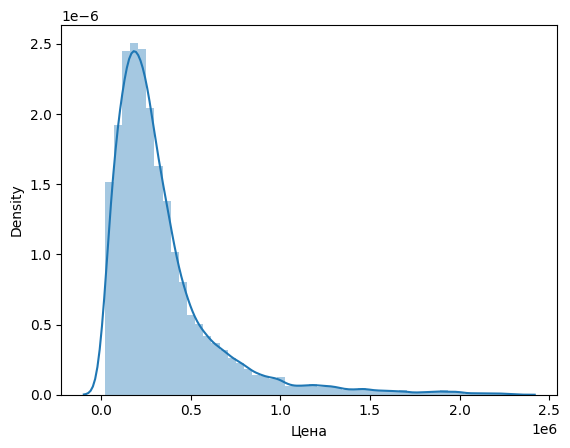

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings

# sns.distplot(data["Цена"]);

In [ ]:
# print("Ассиметрия: %f" % data['Цена'].skew())
# print("Эксцесс: %f" % data['Цена'].kurt())

Ассиметрия: 2.516395
Эксцесс: 8.325256


Приведем цену к нормальному распределению

In [ ]:
# import numpy as np
# data['Цена'] = np.log1p(data['Цена'])

<ipython-input-8-21995222c47e>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Цена"]);


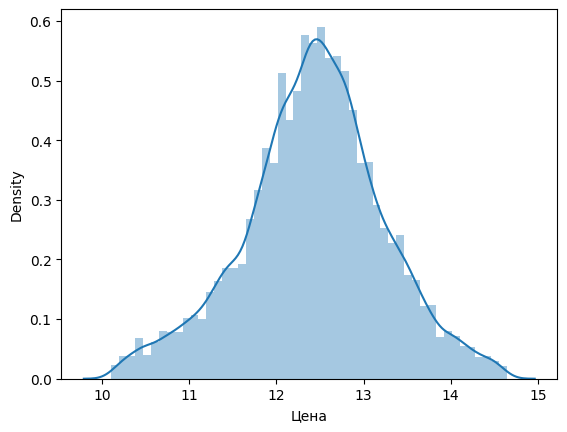

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings

# sns.distplot(data["Цена"]);

После логарифмирования data["Цена"]
ухудшились результаты RandomForestRegressor, поэтому не будем использовать логарифмирование

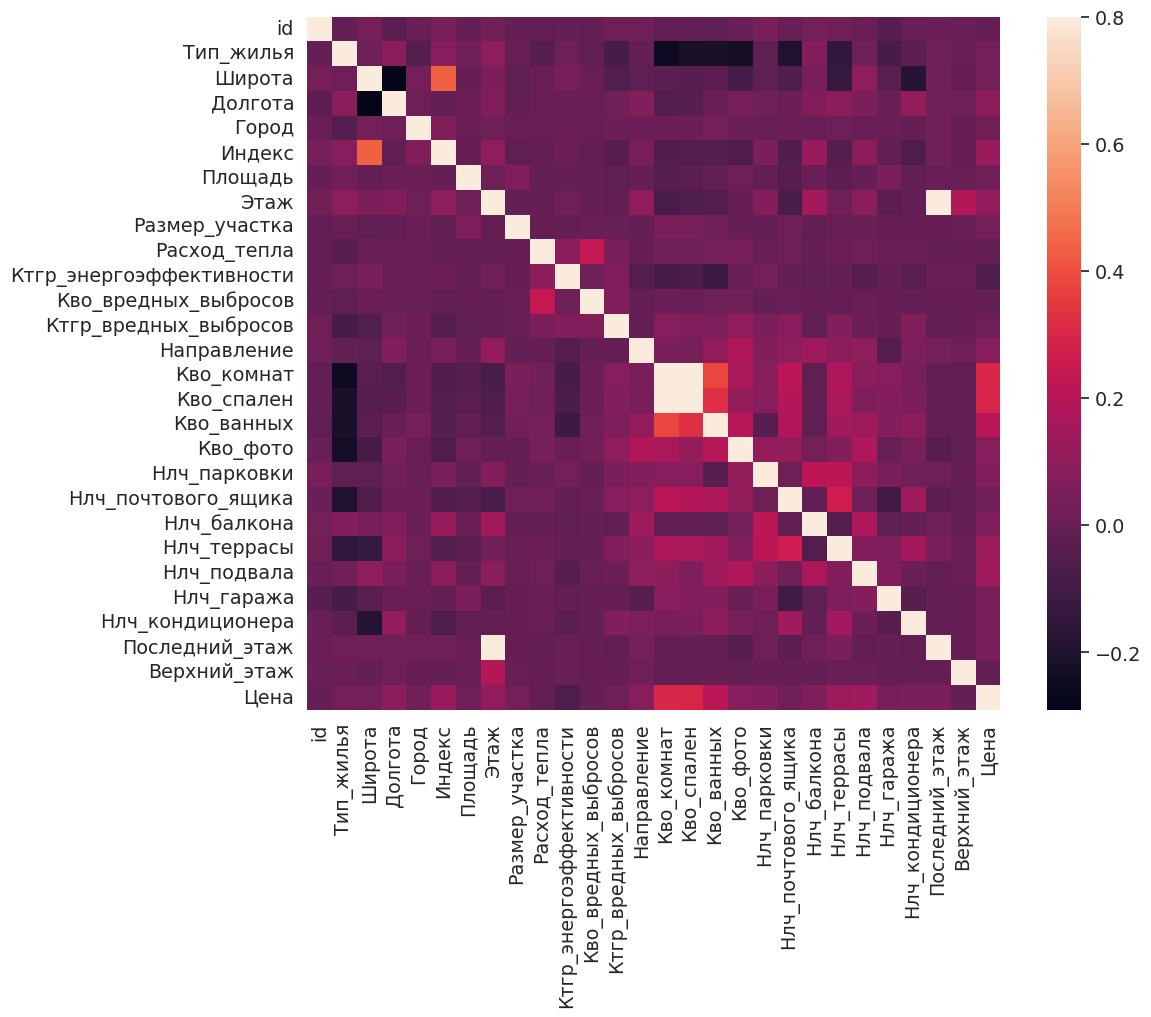

In [ ]:
# corrmat = data.corr()
# f, ax = plt.subplots(figsize=(12, 9))
# sns.heatmap(corrmat, vmax=.8, square=True);

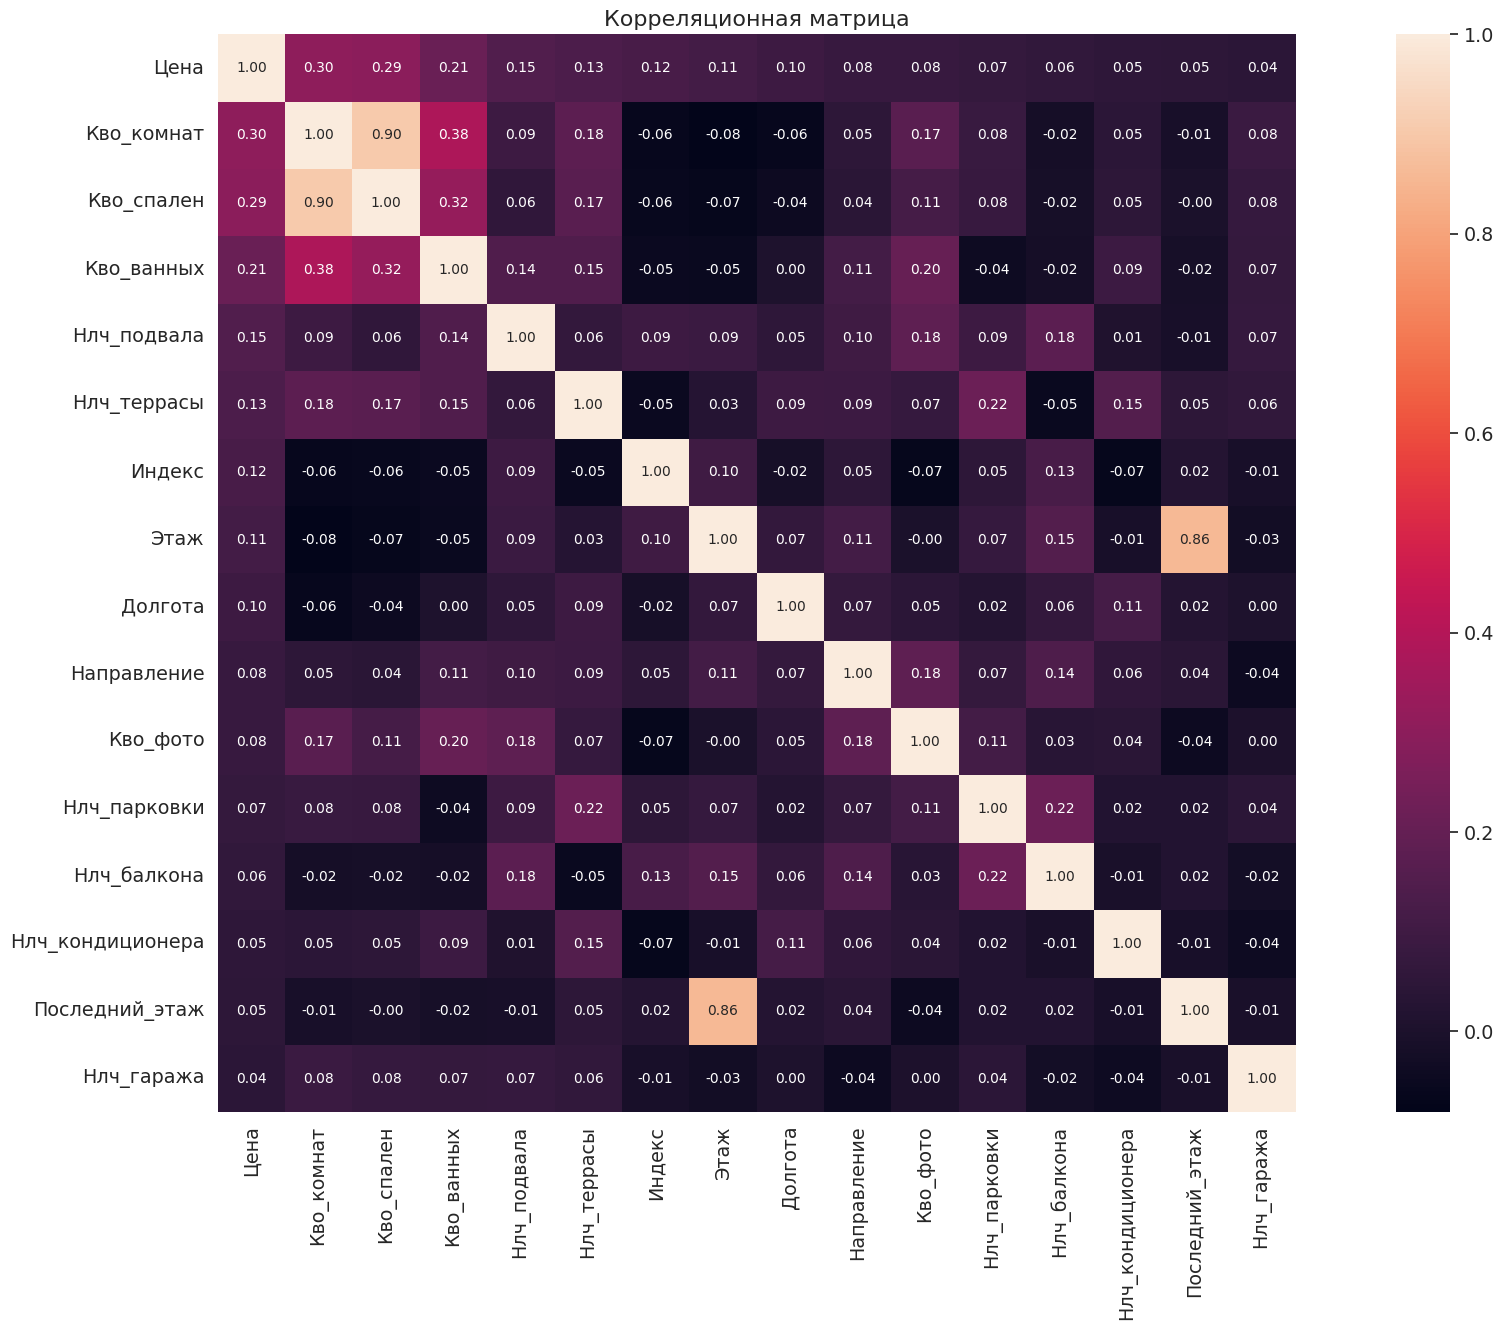

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# k = 16
# cols = corrmat.nlargest(k, 'Цена')['Цена'].index
# cm = np.corrcoef(data[cols].values.T)

# plt.figure(figsize=(26, 14))

# sns.set(font_scale=1.25)
# hm = sns.heatmap(cm, cbar=True, annot=True, square=True,
#                  fmt='.2f', annot_kws={'size': 10},
#                  yticklabels=cols.values, xticklabels=cols.values)

# plt.title('Корреляционная матрица', fontsize=16)
# plt.show()


С ценой коррелируют больше всего Кво_комнат и Кво_спален. Возьмем из этого что-то одно, так как Кво_комнат и Кво_спален коррелируют между собой. Возьмем Кво_комнат. Кво_ванных тоже хорошо коррелирует с ценой, можно взять. Возьмем широту и долготу, так как плохо коррелируют между собой и могут объяснить местоположение объяекта. 'Расход_тепла','Тип_жилья', 'Индекс', 'Площадь', 'Размер_участка', 'Нлч_гаража' ,'Нлч_парковки','Город' наличие этих признаков несет информацию, помогающую оценить стоимость недвижимости. Большая площадь и размер участка, а также наличие гаража и тип жилья могут увеличивать стоимость объекта. Расход_тепла помогает оценить энергоэффективность жилья, что важно для покупателей, пытающихся снизить свои расходы на коммунальные услуги. Индекс и Город могут быть связаны с уровнем доступности и инфраструктурного развития, что значительно влияет на привлекательность недвижимости.

<Axes: xlabel='Кво_фото', ylabel='Цена'>

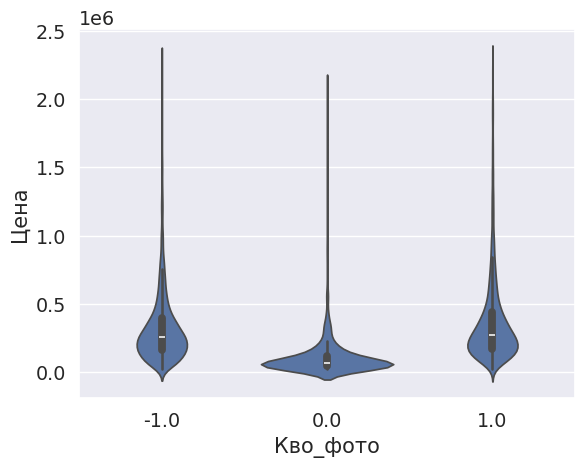

In [ ]:
# sns.violinplot(x=data["Кво_фото"], y=data["Цена"])

Медиана цен для квартир с фотографиями выглядит выше, чем для квартир без фотографий. У квартир с фотографиями более высокий разброс цен, что может указывать на присутствие как более дорогих, так и более дешевых вариантов. Поэтому возьмем этот признак

<Axes: xlabel='Верхний_этаж', ylabel='Цена'>

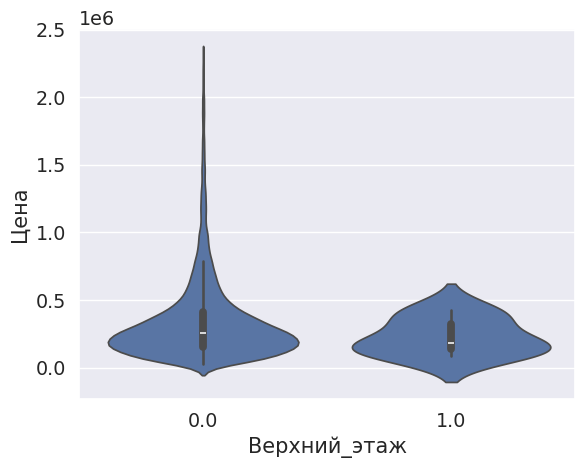

In [ ]:
# sns.violinplot(x=data["Верхний_этаж"], y=data["Цена"])

Медиана цен для квартир с верхним этажом ниже, чем для квартир без верхнего этажа. Это может указывать на предпочтение покупателями квартир без верхнего этажа. У квартирах без верхнего этажа наблюдается большее количество дорогих объектов по сравнению с квартирами с верхним этажом.
Поэтому возьмем этот признак

<Axes: xlabel='Нлч_балкона', ylabel='Цена'>

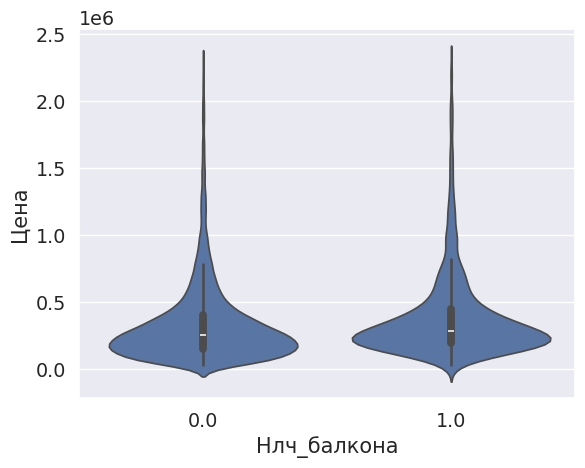

In [ ]:
# sns.violinplot(x=data["Нлч_балкона"], y=data["Цена"])

Медиана цен для квартир с балконом, чуть выше, чем для квартир без балкона. Это может свидетельствовать о более высокой ценности квартир с балконом для покупателей. Квартиры с балконами часто стоят дороже и представлены в более широком ценовом диапазоне.

## **Посмотрим на выбросы**

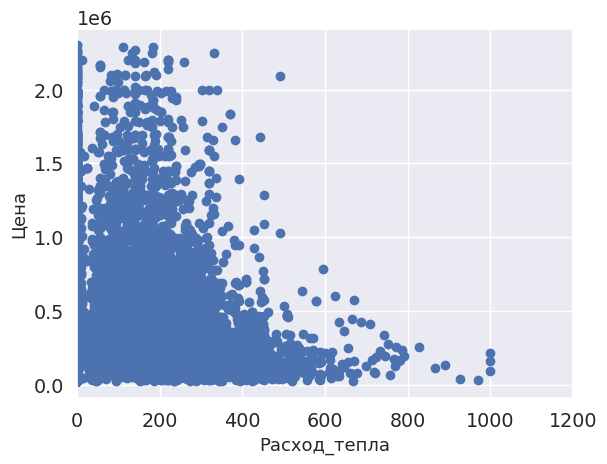

In [ ]:
# fig, ax = plt.subplots()
# ax.scatter(x = data['Расход_тепла'], y = data['Цена'])
# plt.ylabel('Цена', fontsize=13)
# plt.xlabel('Расход_тепла', fontsize=13)
# ax.grid(True)
# plt.xlim(0, 1200)  # Ограничиваем ось X от 20 до 100
# plt.show()

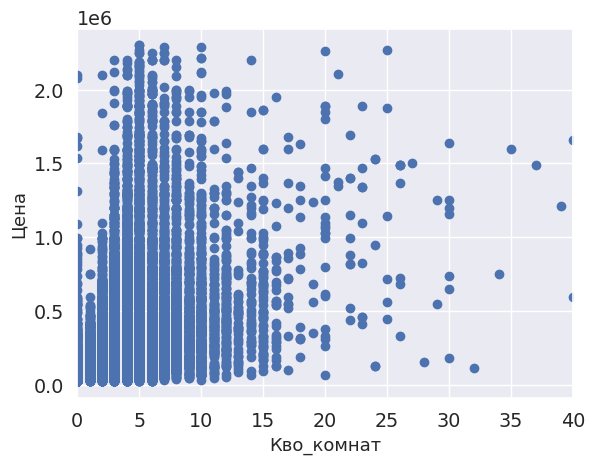

In [ ]:
# fig, ax = plt.subplots()
# ax.scatter(x = data['Кво_комнат'], y = data['Цена'])
# plt.ylabel('Цена', fontsize=13)
# plt.xlabel('Кво_комнат', fontsize=13)
# ax.grid(True)
# plt.xlim(0, 40)
# plt.show()

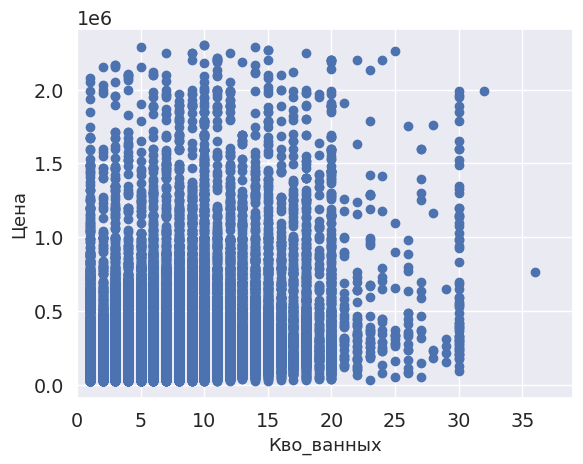

In [ ]:
# fig, ax = plt.subplots()
# ax.scatter(x = data['Кво_ванных'], y = data['Цена'])
# plt.ylabel('Цена', fontsize=13)
# plt.xlabel('Кво_ванных', fontsize=13)
# ax.grid(True)
# plt.xlim(0, 39)
# plt.show()

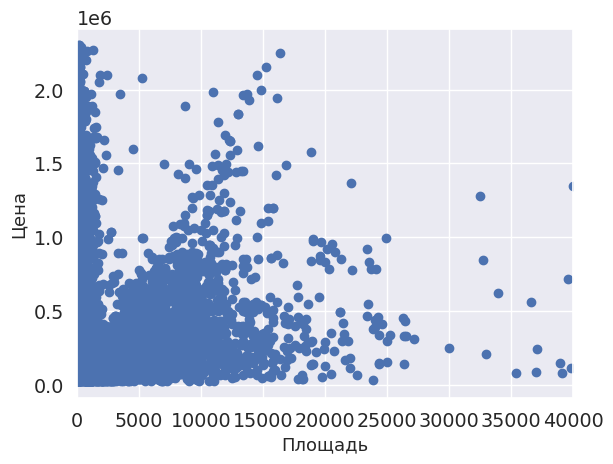

In [ ]:
# fig, ax = plt.subplots()
# ax.scatter(x = data['Площадь'], y = data['Цена'])
# plt.ylabel('Цена', fontsize=13)
# plt.xlabel('Площадь', fontsize=13)
# ax.grid(True)
# plt.xlim(0, 40000)
# plt.show()

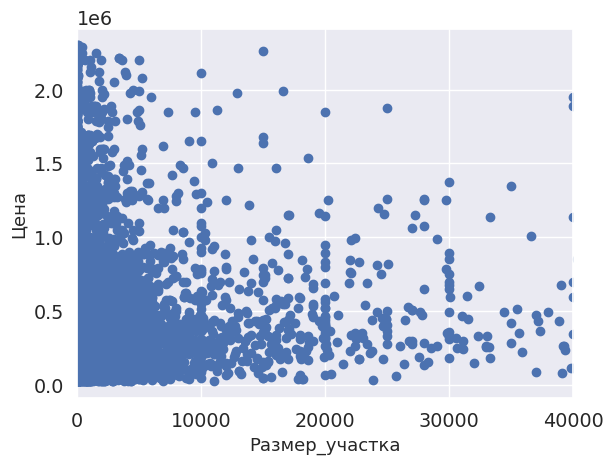

In [ ]:
# fig, ax = plt.subplots()
# ax.scatter(x = data['Размер_участка'], y = data['Цена'])
# plt.ylabel('Цена', fontsize=13)
# plt.xlabel('Размер_участка', fontsize=13)
# ax.grid(True)
# plt.xlim(-2, 40000)  # Ограничиваем ось X от 20 до 100
# plt.show()

## Удаление этих выбросов улучшает результат

In [ ]:

data = data.drop(data[(data['Кво_комнат'] > 20) ].index)
data = data.drop(data[(data['Расход_тепла'] >600) ].index)
data = data.drop(data[(data['Кво_ванных'] > 20)].index)
data = data.drop(data[(data['Площадь'] > 20000) ].index)



In [ ]:

y = data['Цена'].copy()
X = data[['Расход_тепла','Тип_жилья', 'Широта', 'Долгота', 'Индекс', 'Площадь', 'Размер_участка', 'Кво_комнат', 'Кво_ванных', 'Кво_фото','Нлч_гаража' ,'Нлч_парковки','Город', 'Нлч_балкона', 'Верхний_этаж']]


Посмотрим на корреляцию признаков

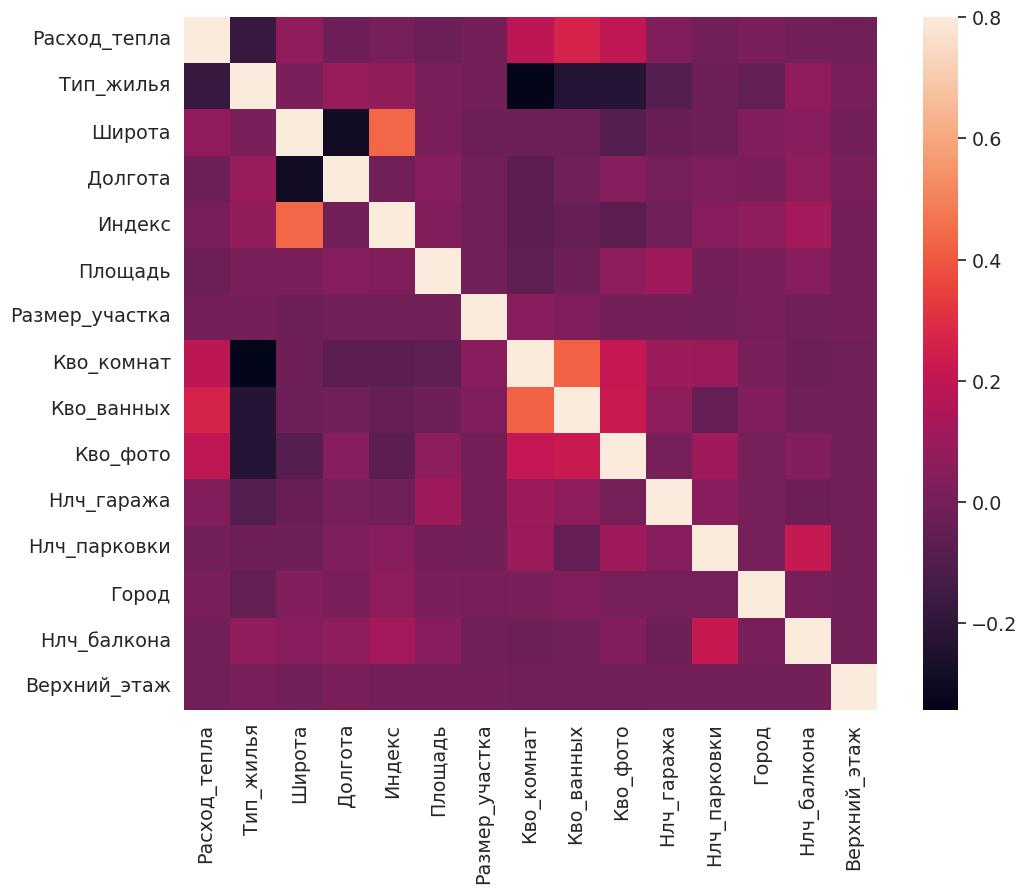

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corrmat = X.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

In [ ]:
from sklearn.model_selection import train_test_split

# Разделение на наборы train, val и test
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=826)

# Модели и обучение

Сравним модели

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error as mape
import xgboost as xg
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import AdaBoostRegressor


models = [
          RandomForestRegressor(n_estimators=300, random_state=826),
          KNeighborsRegressor(n_neighbors=3),
          xg.XGBRegressor(objective='reg:absoluteerror', n_estimators=10, random_state=826),
          Ridge(random_state=826),
          Lasso(alpha=0.1,random_state=826),
          ElasticNet(alpha=1.0, l1_ratio=0.5,random_state=826),
          AdaBoostRegressor(n_estimators=50, random_state=826),
          LinearRegression(),
          MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=826)

          ]

При проверке вашего решения мы будем использовать метрику MAPE, которая показывает на сколько процентов в среднем откланяются предсказанные значения от реальных. Чем ближе MAPE к 0, тем лучше.

In [ ]:
# Создаем DataFrame для хранения результатов
TestModels = pd.DataFrame(columns=['Model', 'R2', 'MSE', 'RMSE', 'MAPE'])

# Итерация по моделям
for model in models:
    m = str(model.__class__.__name__)
    print(m)
    model.fit(X_train, y_train)

    # Вычисляем метрики
    r2_val = r2_score(y_val, model.predict(X_val))
    mse_val = mean_squared_error(y_val, model.predict(X_val))
    mape_val = mape(y_val, model.predict(X_val))

    # Добавляем результаты в DataFrame
    tmp = pd.DataFrame({'Model': [m], 'R2': [r2_val],
                        'MSE': [mse_val], 'RMSE': [np.sqrt(mse_val)],
                        'MAPE': [mape_val]} )
    TestModels = pd.concat([TestModels, tmp], ignore_index=True)

TestModels.set_index('Model', inplace=True)
print(TestModels)

RandomForestRegressor


<ipython-input-52-04f25279680f>:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  TestModels = pd.concat([TestModels, tmp], ignore_index=True)


KNeighborsRegressor
XGBRegressor
Ridge
Lasso
ElasticNet
AdaBoostRegressor
LinearRegression
MLPRegressor
                             R2           MSE           RMSE      MAPE
Model                                                                 
RandomForestRegressor  0.754967  2.189033e+10  147953.801864  0.391055
KNeighborsRegressor    0.377402  5.562064e+10  235840.288325  0.672637
XGBRegressor           0.514508  4.337206e+10  208259.587059  0.426997
Ridge                  0.157127  7.529924e+10  274407.069642  0.885302
Lasso                  0.157127  7.529919e+10  274406.974392  0.885312
ElasticNet             0.155067  7.548327e+10  274742.179841  0.902528
AdaBoostRegressor     -0.491116  1.332109e+11  364980.705804  2.068826
LinearRegression       0.157127  7.529918e+10  274406.966377  0.885313
MLPRegressor           0.078137  8.235592e+10  286977.213906  0.996749


Наилучший результат у RandomForestRegressor

#Тестирование модели и сохранение файла .csv

Подгружаем файлы

In [ ]:
import pandas as pd
# from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import AdaBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

data_test = pd.read_csv('private_test.csv')

# Устраняем NaN
data_test.fillna(-1, inplace=True)

from sklearn.preprocessing import LabelEncoder

# Создаем объект LabelEncoder
le = LabelEncoder()

# Применяем LabelEncoder к столбцу 'Тип_жилья'
data_test['Тип_жилья'] = le.fit_transform(data_test['Тип_жилья'])


type_town = pd.unique(data_test['Город'])
for i in range(len(type_town)):
    data_test['Город'] = data_test['Город'].replace(type_town[i], len(type_town[i]))


# type_h=pd.unique(data_test['Ктгр_энергоэффективности'])
# for i in range(len(type_h)):
#     data_test['Ктгр_энергоэффективности'] = data_test['Ктгр_энергоэффективности'].replace(type_h[i], i + 1)

# type_he=pd.unique(data_test['Ктгр_вредных_выбросов'])
# for i in range(len(type_he)):
#     data_test['Ктгр_вредных_выбросов'] = data_test['Ктгр_вредных_выбросов'].replace(type_he[i], i + 1)

# type_n=pd.unique(data_test['Направление'])
# for i in range(len(type_n)):
#     data_test['Направление'] = data_test['Направление'].replace(type_n[i], i + 1)





/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:

X_test =data_test[['Расход_тепла','Тип_жилья', 'Широта', 'Долгота', 'Индекс', 'Площадь', 'Размер_участка', 'Кво_комнат', 'Кво_ванных', 'Кво_фото','Нлч_гаража' ,'Нлч_парковки','Город', 'Нлч_балкона', 'Верхний_этаж']] #71.74


model= RandomForestRegressor(n_estimators=500 , random_state=826)


model.fit(X, y)
y_pred = model.predict(X_test)



Сохраняем словарь в виде файла .csv сразу на диск. Не забудьте прописать seed  в имени файла!

In [ ]:
df = pd.DataFrame({'id': data_test['id'], 'Цена': y_pred})

# Сохраните DataFrame в CSV-файл
df.to_csv(f'seed_{826}.csv', index=False)